# Market Regime Detection with Hidden Markov Models and Regime Based Portfolio-Allocation
## _Written by Matteo Cunsolo_

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

In [25]:
SMI=pd.read_csv("SMI.csv",header=0,index_col=0,parse_dates=True,na_values=-99.99)
#calculating returns
SMI["Returns"]=SMI["Close"].pct_change()
#deleting not needed stuff
SMI= SMI.drop(columns=["Volume", "High", "Low", "Open"])
SMI.columns=["Price","Returns"]
SMI=SMI.dropna()
SMI["Roll Vol 30d"] = np.nan
# calculating rolling volatilty
rw=30
counts=0
for date, row in SMI.iterrows():
    counts=counts+1
    if counts>rw:
        window=(SMI["Returns"].iloc[counts-rw:counts]).astype(float)
        SMI.loc[date, "Roll Vol 30d"] = window.std()*np.sqrt(252)   
SMI=SMI.dropna()

# Input matrix

In [38]:
inmatrix=SMI.drop(columns=["Price"])
model = GaussianHMM(n_components=3,covariance_type="full",n_iter=1000,random_state=42)
model.fit(inmatrix)
states = model.predict(inmatrix)
SMI["State"] =SMI["State"] = states
SMI

,Price,Returns,Roll Vol 30d,State
Date,,,,
1988-08-16,1492.20,-0.012311,0.119581,1
1988-08-17,1517.50,0.016955,0.127404,1
1988-08-18,1505.80,-0.007710,0.122244,1
1988-08-19,1509.00,0.002125,0.122047,1
1988-08-22,1515.10,0.004042,0.120607,1
...,...,...,...,...
2026-03-06,13095.55,-0.015246,0.153629,2
2026-03-09,13000.09,-0.007289,0.155043,2
2026-03-10,13065.19,0.005008,0.154840,2


In [39]:
model = GaussianHMM(n_components=3,covariance_type="full",n_iter=1000,random_state=42)
model.fit(inmatrix)
states = model.predict(inmatrix)
SMI["State"] =SMI["State"] = states
SMI

,Price,Returns,Roll Vol 30d,State
Date,,,,
1988-08-16,1492.20,-0.012311,0.119581,1
1988-08-17,1517.50,0.016955,0.127404,1
1988-08-18,1505.80,-0.007710,0.122244,1
1988-08-19,1509.00,0.002125,0.122047,1
1988-08-22,1515.10,0.004042,0.120607,1
...,...,...,...,...
2026-03-06,13095.55,-0.015246,0.153629,2
2026-03-09,13000.09,-0.007289,0.155043,2
2026-03-10,13065.19,0.005008,0.154840,2


In [40]:
SMI.groupby("State")[["Returns","Roll Vol 30d"]].mean()

,Returns,Roll Vol 30d
State,,
0,-0.000108,0.290823
1,0.000517,0.101441
2,0.000196,0.155227


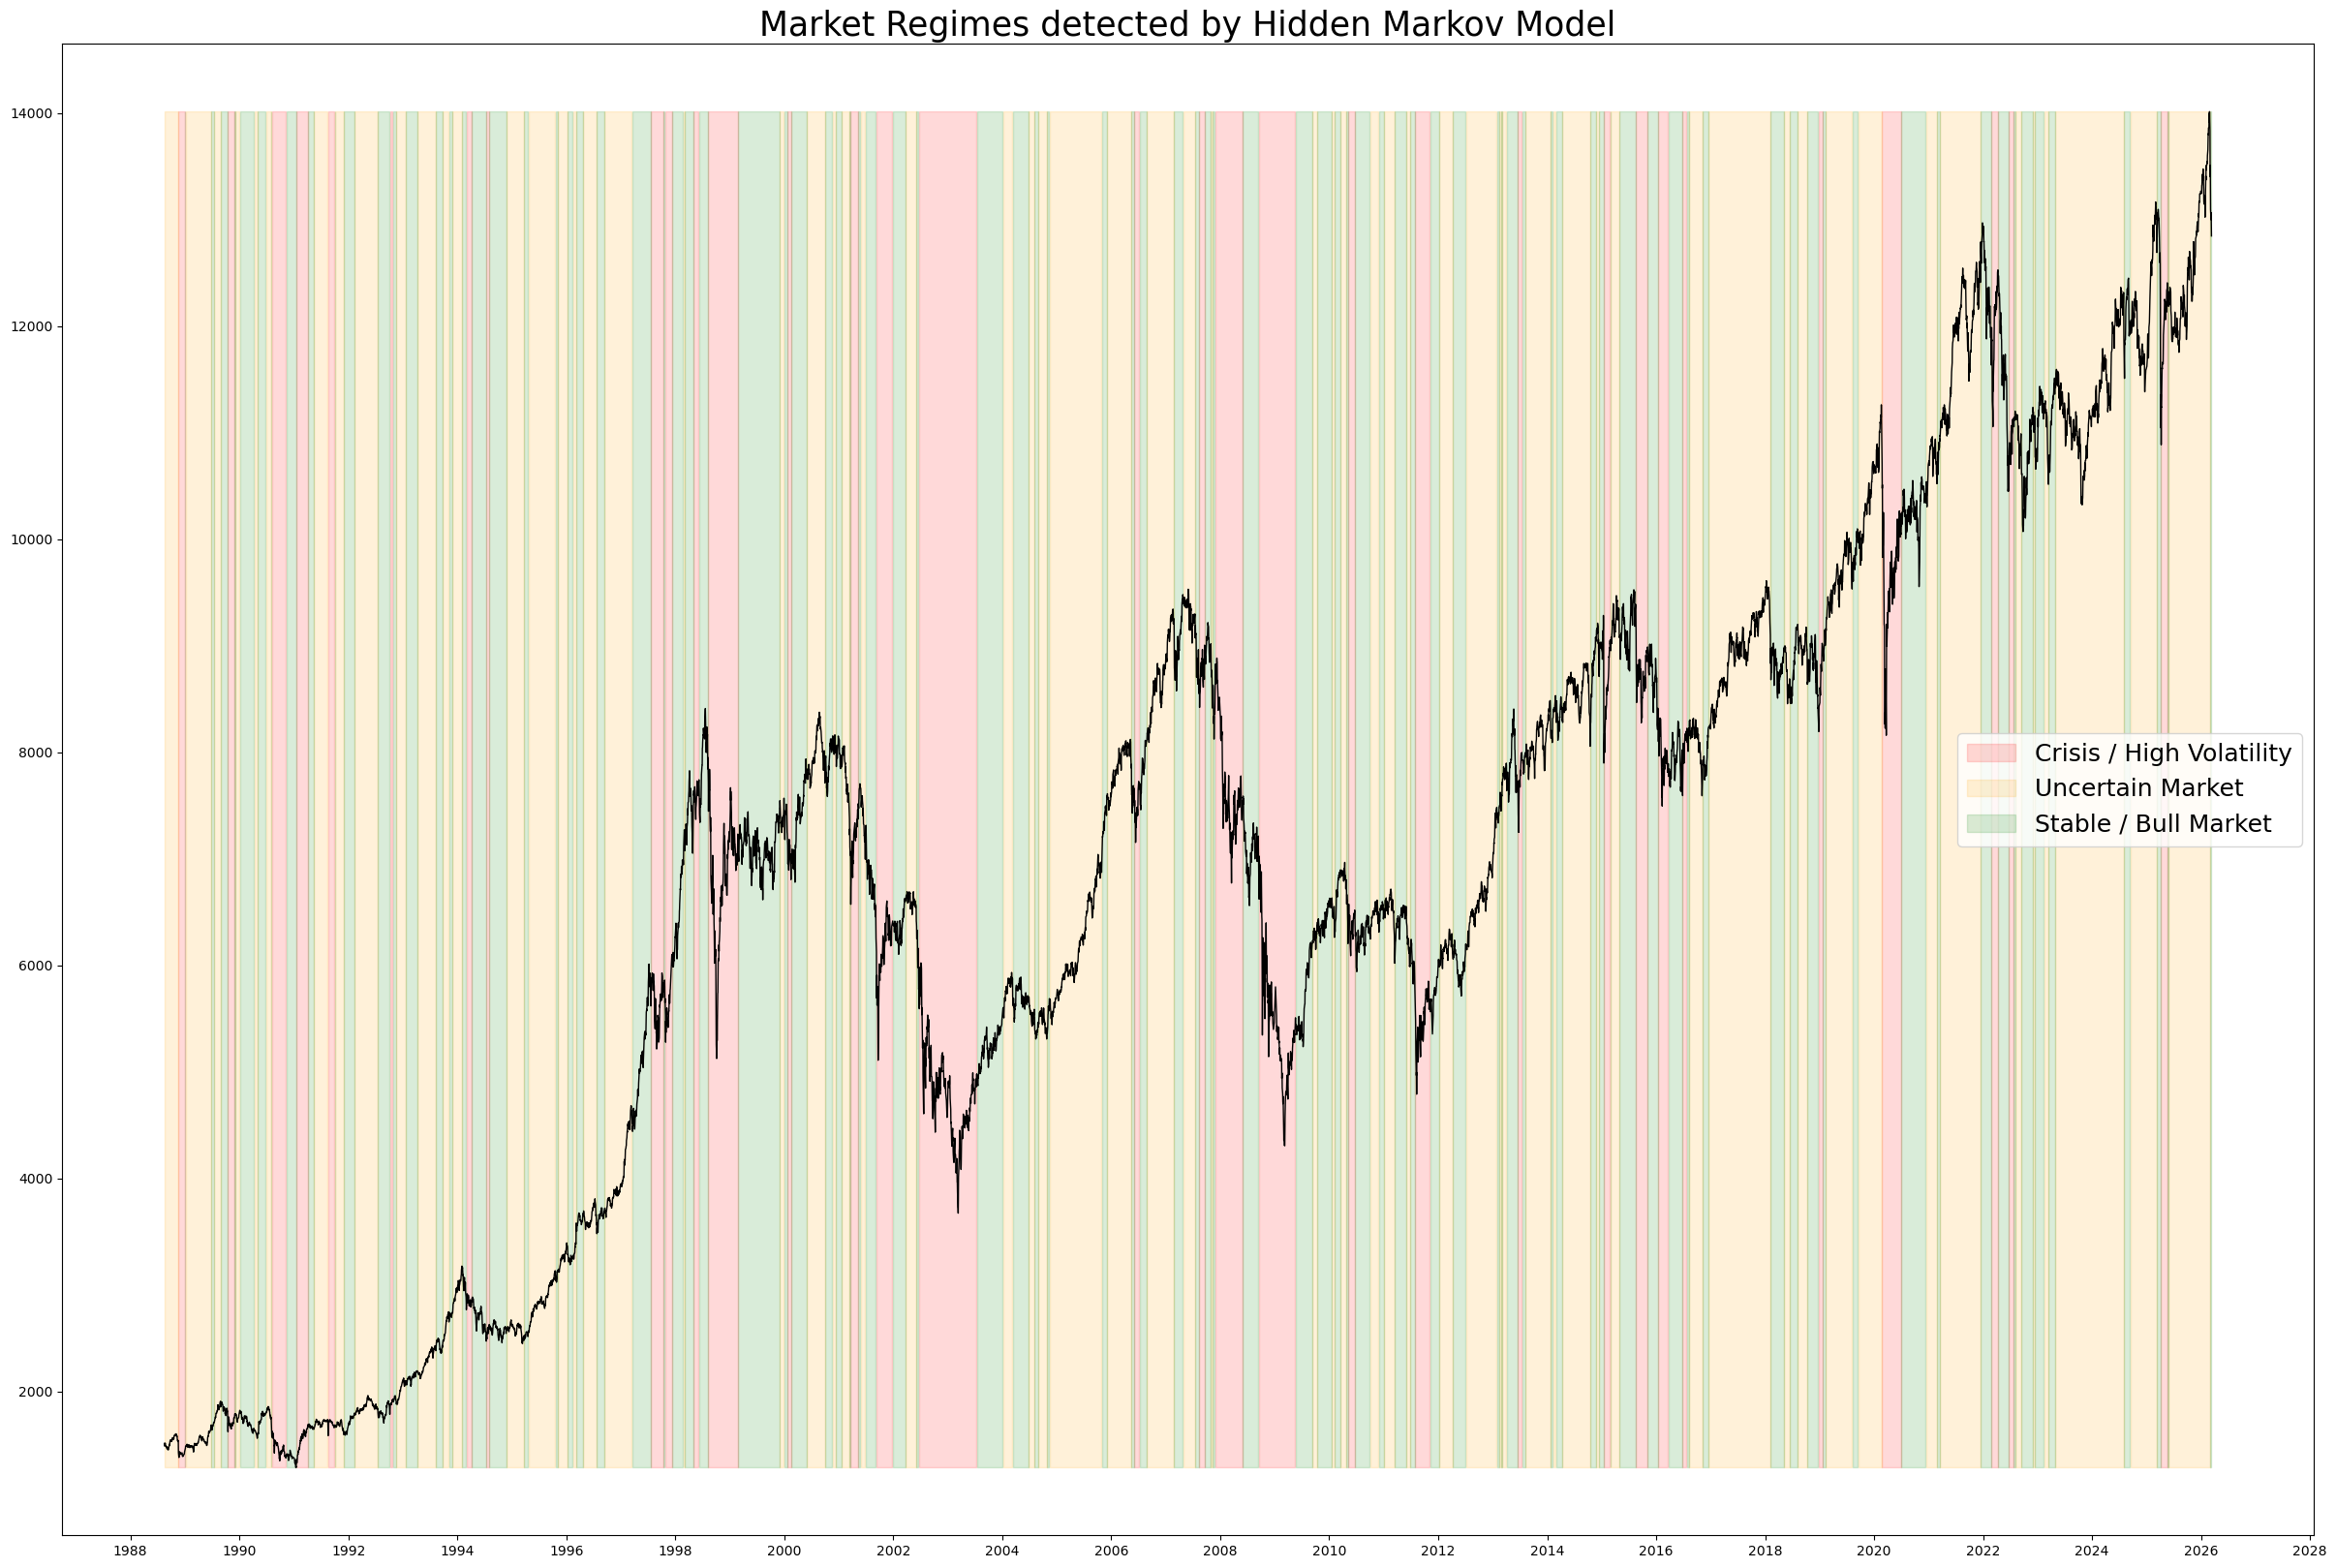

In [62]:
import matplotlib.dates as mdates

plt.figure(figsize=(30,20))
plt.plot(SMI.index, SMI["Price"], color="black", linewidth=1)

colors = ["red","orange","green"]
names = ["Crisis / High Volatility", "Uncertain Market", "Stable / Bull Market"]

for i in range(3):
    plt.fill_between(
        SMI.index,
        SMI["Price"].min(),
        SMI["Price"].max(),
        where=(SMI["State"] == i),
        color=colors[i],
        alpha=0.15,
        label=names[i]
    )

ax = plt.gca()

# mostra un anno ogni 2 anni
ax.xaxis.set_major_locator(mdates.YearLocator(2))


plt.title("Market Regimes detected by Hidden Markov Model", fontsize=25)
plt.legend(fontsize=18)

plt.show()